--- CZĘŚĆ 1: Pozyskiwanie danych ---
Kształt DataFrame: (250, 7)

Typy danych:
nazwa               str
stolica             str
region              str
subregion           str
populacja         int64
powierzchnia    float64
waluta              str
dtype: object

Podgląd (head):
                            nazwa       stolica   region         subregion  \
0                            Iran        Tehran     Asia     Southern Asia   
1                         Albania        Tirana   Europe  Southeast Europe   
2               Wallis and Futuna      Mata-Utu  Oceania         Polynesia   
3                         Belgium      Brussels   Europe    Western Europe   
4  British Indian Ocean Territory  Diego Garcia   Africa    Eastern Africa   

   populacja  powierzchnia waluta  
0   85961000     1648195.0    IRR  
1    2363314       28748.0    ALL  
2      11620         142.0    XPF  
3   11825551       30528.0    EUR  
4          0          60.0    USD  


--- CZĘŚĆ 2: Zapis do bazy SQLite -

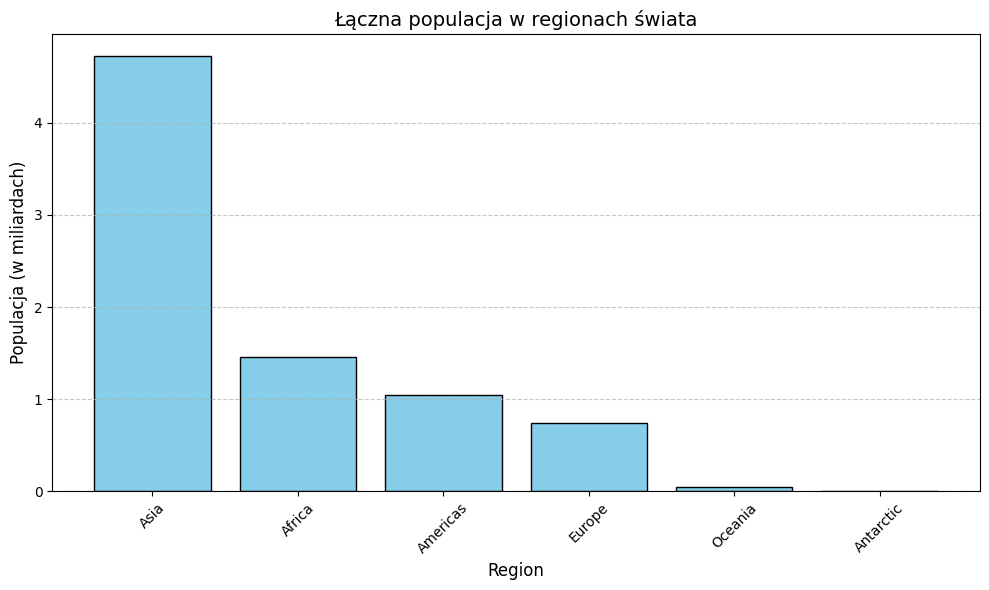

In [3]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# ==========================================
# CZĘŚĆ 1 — Pozyskanie danych (API → DataFrame)
# ==========================================
print("--- CZĘŚĆ 1: Pozyskiwanie danych ---")

# ZAKTUALIZOWANY ADRES URL: Podajemy dokładnie te pola, o które prosi API
url = "https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,currencies"
response = requests.get(url)
response.raise_for_status()  # Rzuca wyjątek w razie błędu HTTP
data = response.json()

def get_currency(currencies_dict):
    """Wyciąga kod pierwszej waluty z zagnieżdżonego słownika."""
    if currencies_dict and isinstance(currencies_dict, dict):
        return list(currencies_dict.keys())[0]
    return None

kraje_lista = []

# Ekstrakcja wymaganych danych dla każdego kraju
for kraj in data:
    kraje_lista.append({
        "nazwa": kraj.get("name", {}).get("common"),
        "stolica": kraj.get("capital", [None])[0] if kraj.get("capital") else None,
        "region": kraj.get("region"),
        "subregion": kraj.get("subregion"),
        "populacja": kraj.get("population", 0),
        "powierzchnia": kraj.get("area", 0.0),
        "waluta": get_currency(kraj.get("currencies"))
    })

# Konwersja do Pandas DataFrame
df_kraje = pd.DataFrame(kraje_lista)

print(f"Kształt DataFrame: {df_kraje.shape}\n")
print(f"Typy danych:\n{df_kraje.dtypes}\n")
print("Podgląd (head):")
print(df_kraje.head())
print("\n" + "="*50 + "\n")


# ==========================================
# CZĘŚĆ 2 — Zapis do bazy SQLite
# ==========================================
print("--- CZĘŚĆ 2: Zapis do bazy SQLite ---")
conn = sqlite3.connect("kraje_swiata.db")

df_kraje.to_sql("kraje", conn, if_exists="replace", index=False)
print("Pomyślnie zapisano DataFrame do tabeli 'kraje' w bazie 'kraje_swiata.db'.")
print("\n" + "="*50 + "\n")


# ==========================================
# CZĘŚĆ 3 — Analiza SQL
# ==========================================
print("--- CZĘŚĆ 3: Analiza SQL ---")

# 1. Jaka jest łączna populacja świata?
df_total_pop = pd.read_sql_query("SELECT SUM(populacja) AS laczna_populacja_swiata FROM kraje", conn)
print("1. Łączna populacja świata:")
print(df_total_pop)
print("-" * 30)

# 2. Które 10 krajów ma największą populację?
df_top_10_pop = pd.read_sql_query("""
    SELECT nazwa, populacja 
    FROM kraje 
    ORDER BY populacja DESC 
    LIMIT 10
""", conn)
print("2. Top 10 krajów z największą populacją:")
print(df_top_10_pop)
print("-" * 30)

# 3. Ile krajów jest w każdym regionie i jaka jest ich średnia populacja?
df_region_stats = pd.read_sql_query("""
    SELECT 
        region, 
        COUNT(*) AS liczba_krajow, 
        ROUND(AVG(populacja), 0) AS srednia_populacja 
    FROM kraje 
    WHERE region IS NOT NULL AND region != ''
    GROUP BY region 
    ORDER BY liczba_krajow DESC
""", conn)
print("3. Statystyki regionów (liczba krajów i średnia populacja):")
print(df_region_stats)
print("-" * 30)

# 4. Które kraje mają powierzchnię większą niż Polska (~312 679 km²)?
df_wieksze_od_pl = pd.read_sql_query("""
    SELECT nazwa, powierzchnia 
    FROM kraje 
    WHERE powierzchnia > 312679 
    ORDER BY powierzchnia DESC
""", conn)
print(f"4. Kraje większe od Polski (jest ich {len(df_wieksze_od_pl)}):")
print(df_wieksze_od_pl.head(10)) 
print("-" * 30)

# 5. Który kraj ma najwyższą gęstość zaludnienia (populacja / powierzchnia)?
df_max_density = pd.read_sql_query("""
    SELECT 
        nazwa, 
        populacja, 
        powierzchnia,
        (populacja / powierzchnia) AS gestosc_zaludnienia 
    FROM kraje 
    WHERE powierzchnia > 0 
    ORDER BY gestosc_zaludnienia DESC 
    LIMIT 1
""", conn)
print("5. Kraj z najwyższą gęstością zaludnienia:")
print(df_max_density)
print("\n" + "="*50 + "\n")


# ==========================================
# CZĘŚĆ 4 — Wizualizacja
# ==========================================
print("--- CZĘŚĆ 4: Wizualizacja ---")

df_plot = pd.read_sql_query("""
    SELECT region, SUM(populacja) AS laczna_populacja 
    FROM kraje 
    WHERE region IS NOT NULL AND region != ''
    GROUP BY region 
    ORDER BY laczna_populacja DESC
""", conn)

plt.figure(figsize=(10, 6))
plt.bar(df_plot["region"], df_plot["laczna_populacja"] / 1e9, color='skyblue', edgecolor='black')

plt.title("Łączna populacja w regionach świata", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Populacja (w miliardach)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

conn.close()